In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.ensemble import IsolationForest
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully! ✅")

All libraries imported successfully! ✅


In [2]:
# Cell 2 — Fetch Stock Data
ticker = "AAPL"  # Apple Stock (we can change this later)
df = yf.download(ticker, start="2020-01-01", end="2024-12-31")

print(f"Data Shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

[*********************100%***********************]  1 of 1 completed

Data Shape: (1257, 5)

First 5 rows:


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400
2020-01-03,71.630638,72.389257,71.406666,71.563205,146322800
2020-01-06,72.201424,72.239958,70.503561,70.754028,118387200
2020-01-07,71.861839,72.466322,71.642681,72.211041,108872000
2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200


In [3]:
# Cell 3 — Check & Clean Data
print("Column Names:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nBasic Statistics:")
df.describe()

Column Names: [('Close', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Open', 'AAPL'), ('Volume', 'AAPL')]

Data Types:
 Price   Ticker
Close   AAPL      float64
High    AAPL      float64
Low     AAPL      float64
Open    AAPL      float64
Volume  AAPL        int64
dtype: object

Missing Values:
 Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

Basic Statistics:


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1257.000000,1257.000000,1257.000000,1257.000000,1.257000e+03
mean,151.300259,152.820989,149.602777,151.144223,9.061168e+07
std,41.778189,41.916450,41.553582,41.717783,5.324605e+07
min,54.163700,55.160698,51.324796,55.059309,2.323470e+07
25%,126.249901,127.334371,124.234815,125.724384,5.546960e+07
50%,149.942184,151.690633,147.948354,149.768134,7.629970e+07
75%,175.746490,177.445018,174.316253,175.593390,1.077601e+08
max,257.375580,258.448740,255.994420,256.550862,4.265100e+08


In [4]:
# Cell 4 — Flatten Column Names
df.columns = df.columns.get_level_values(0)
df = df.reset_index()

print("Cleaned Column Names:", df.columns.tolist())
df.head()

Cleaned Column Names: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']


Price,Date,Close,High,Low,Open,Volume
0,2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400
1,2020-01-03,71.630638,72.389257,71.406666,71.563205,146322800
2,2020-01-06,72.201424,72.239958,70.503561,70.754028,118387200
3,2020-01-07,71.861839,72.466322,71.642681,72.211041,108872000
4,2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200


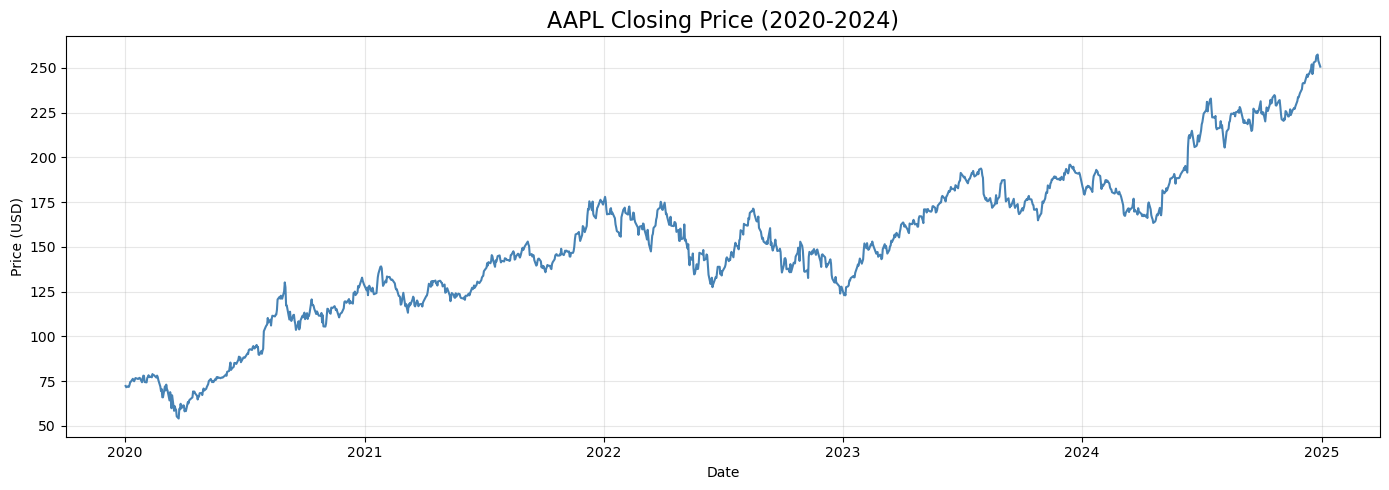

Chart saved! ✅


In [5]:
# Cell 5 — Plot Closing Price
plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['Close'], color='steelblue', linewidth=1.5)
plt.title('AAPL Closing Price (2020-2024)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('closing_price.png', dpi=150)
plt.show()
print("Chart saved! ✅")

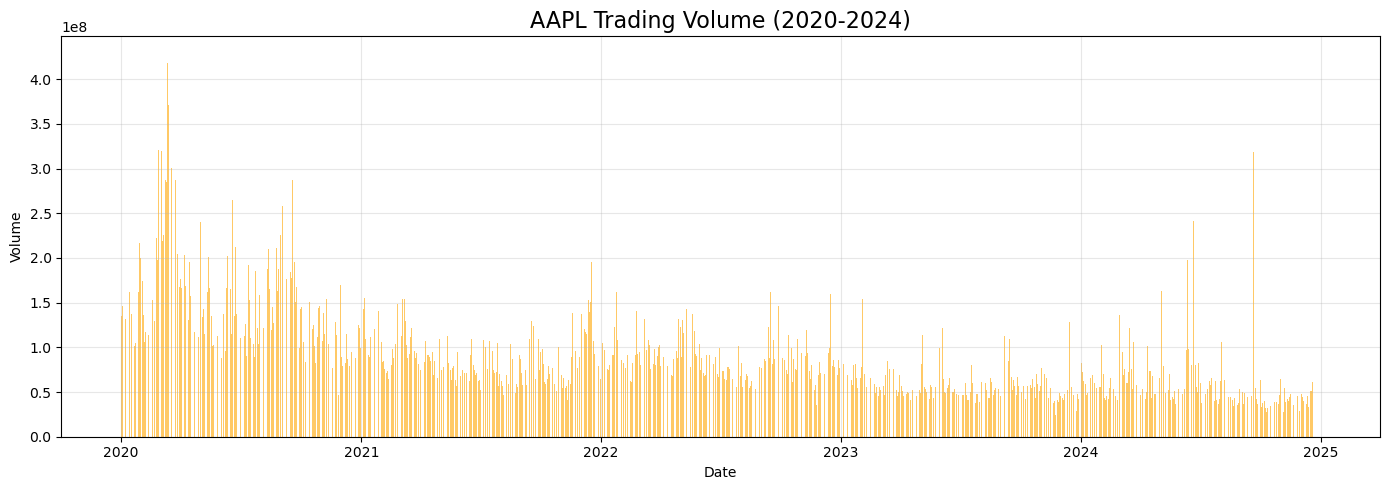

Chart saved! ✅


In [8]:
# Cell 6 — Plot Volume
plt.figure(figsize=(14, 5))
plt.bar(df['Date'], df['Volume'], color='orange', alpha=0.6)
plt.title('AAPL Trading Volume (2020-2024)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('volume.png', dpi=150)
plt.show()
print("Chart saved! ✅")

In [9]:
# Cell 7 — Anomaly Detection using Isolation Forest
# Prepare features
features = df[['Close', 'Volume']].copy()

# Apply Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df['Anomaly'] = iso_forest.fit_predict(features)

# -1 = Anomaly, 1 = Normal
anomalies = df[df['Anomaly'] == -1]

print(f"Total Anomalies Detected: {len(anomalies)}")
print(f"\nFirst 5 Anomalies:")
anomalies[['Date', 'Close', 'Volume']].head()

Total Anomalies Detected: 63

First 5 Anomalies:


Price,Date,Close,Volume
18,2020-01-29,78.111435,216229200
35,2020-02-24,71.981689,222195200
36,2020-02-25,69.543510,230673600
38,2020-02-27,66.028687,320605600
39,2020-02-28,65.990082,426510000


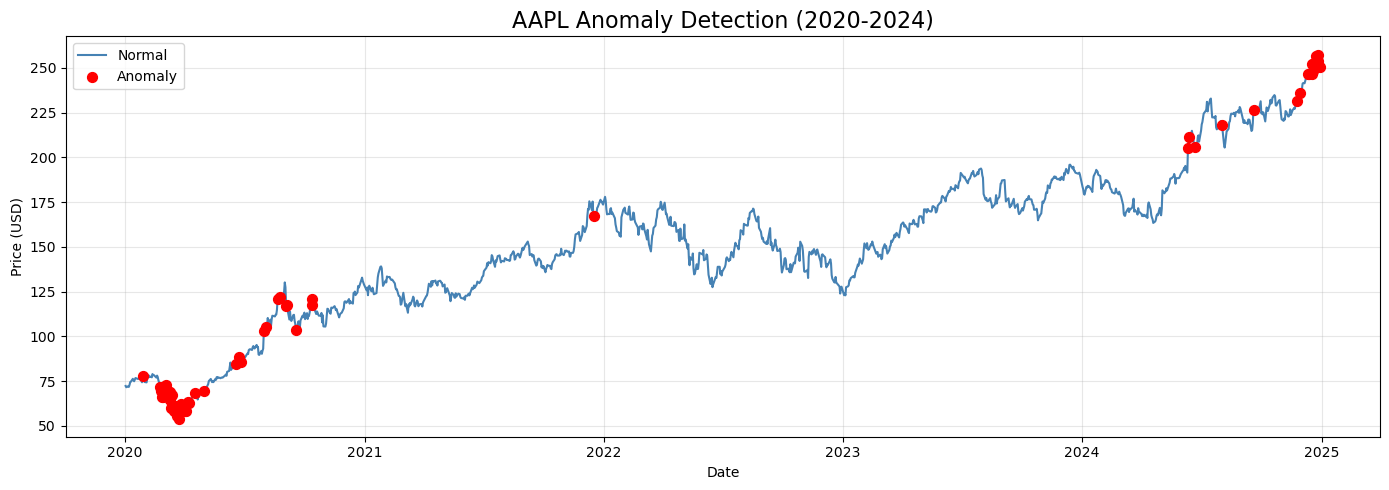

Chart saved! ✅


In [10]:
# Cell 8 — Visualize Anomalies
plt.figure(figsize=(14, 5))

# Normal points
plt.plot(df['Date'], df['Close'], 
         color='steelblue', linewidth=1.5, label='Normal')

# Anomaly points
plt.scatter(anomalies['Date'], anomalies['Close'], 
            color='red', s=50, zorder=5, label='Anomaly')

plt.title('AAPL Anomaly Detection (2020-2024)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('anomaly_detection.png', dpi=150)
plt.show()
print("Chart saved! ✅")